# Time Series Local Change
**Author:** Alejandro Orellana

**Date:** Feburary 12, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

In [1]:
from utils.data_utils import load_data
from utils.fix_effect_utils import (
    map_community,
    ols_compare_and_pred_plot,
    plotting_r_sqared,
    prepared_dataframe,
)

analysis_df = prepared_dataframe(load_data())
target_col = "Site EUI (kBtu/sq ft)"
analysis_df["geo_mapped_name"] = analysis_df["Community Area"].apply(map_community)
analysis_df = analysis_df.sort_values(["ID", "Data Year"])

2026-02-19 21:02:04,162 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-02-19 21:02:04,165 [INFO] Category counts:
COVID Impact Category
Other                   505
Permanent              1813
Stable/Increased       7470
Temporary/Rebounded    1716


In [2]:
analysis_df["next_year_eui"] = analysis_df.groupby("ID")[target_col].shift(-1)
analysis_df["building_future_change"] = (
    analysis_df["next_year_eui"] - analysis_df[target_col]
)

city_trend = analysis_df.groupby("Data Year")["building_future_change"].transform(
    "mean"
)

analysis_df["target_relative_growth"] = (
    analysis_df["building_future_change"] - city_trend
)

In [3]:
filling_cols = ["Gross Floor Area - Buildings (sq ft)", "Year Built"]
for col in filling_cols:
    analysis_df[col] = analysis_df.groupby("ID")[col].transform(
        lambda x: x.ffill().bfill()
    )

analysis_df["Building_Age"] = analysis_df["Data Year"] - analysis_df["Year Built"]

In [ ]:
remove_year = 2016
cut_off_year = 2022
analysis_df["previous_relative_growth"] = analysis_df.groupby("ID")[
    "target_relative_growth"
].shift(1)
analysis_df["Site_EUI_Lag1"] = analysis_df.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(
    1
)
analysis_df["Site_EUI_Lag2"] = analysis_df.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(
    2
)
analysis_df["Momentum"] = analysis_df["Site_EUI_Lag1"] - analysis_df["Site_EUI_Lag2"]

analysis_df = analysis_df[analysis_df["Data Year"] != remove_year]
train_df = analysis_df[analysis_df["Data Year"] < cut_off_year]
test_df = analysis_df[analysis_df["Data Year"] == cut_off_year]
print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")
# test_df = test_df[test_df["Data Year"] < 2023]
analysis_df[
    [
        "Data Year",
        "ID",
        "Year Built",
        "Building_Age",
        "Gross Floor Area - Buildings (sq ft)",
        "Site EUI (kBtu/sq ft)",
        "next_year_eui",
        "building_future_change",
        "target_relative_growth",
        "previous_relative_growth",
        "Momentum",
    ]
]

Training Samples: 6400 | Testing Samples: 1280


,Data Year,ID,Year Built,Building_Age,Gross Floor Area - Buildings (sq ft),Site EUI (kBtu/sq ft),next_year_eui,building_future_change,target_relative_growth,previous_relative_growth,Momentum
2543,2017,100001,1928.0,89.0,309056.0,182.6,188.8,6.2,2.000942,-7.238836,NaN
28282,2018,100001,1928.0,90.0,309056.0,188.8,178.3,-10.5,-9.471609,2.000942,-7.8
20009,2019,100001,1928.0,91.0,309056.0,178.3,175.0,-3.3,6.363478,-9.471609,6.2
6268,2020,100001,1928.0,92.0,505417.0,175.0,171.0,-4.0,-4.055769,6.363478,-10.5
12826,2021,100001,1928.0,93.0,505417.0,171.0,164.0,-7.0,-10.982120,-4.055769,-3.3
...,...,...,...,...,...,...,...,...,...,...,...
23377,2019,260184,1970.0,49.0,140000.0,129.3,114.8,-14.5,-4.836522,-15.071609,22.5
4021,2020,260184,1970.0,50.0,170000.0,114.8,117.6,2.8,2.744231,-4.836522,-16.1
12734,2021,260184,1970.0,51.0,170000.0,117.6,114.7,-2.9,-6.882120,2.744231,-14.5
7812,2022,260184,1970.0,52.0,170000.0,114.7,115.0,0.3,6.735680,-6.882120,2.8


# Plotting R-square

Running OLS on Target: target_relative_growth


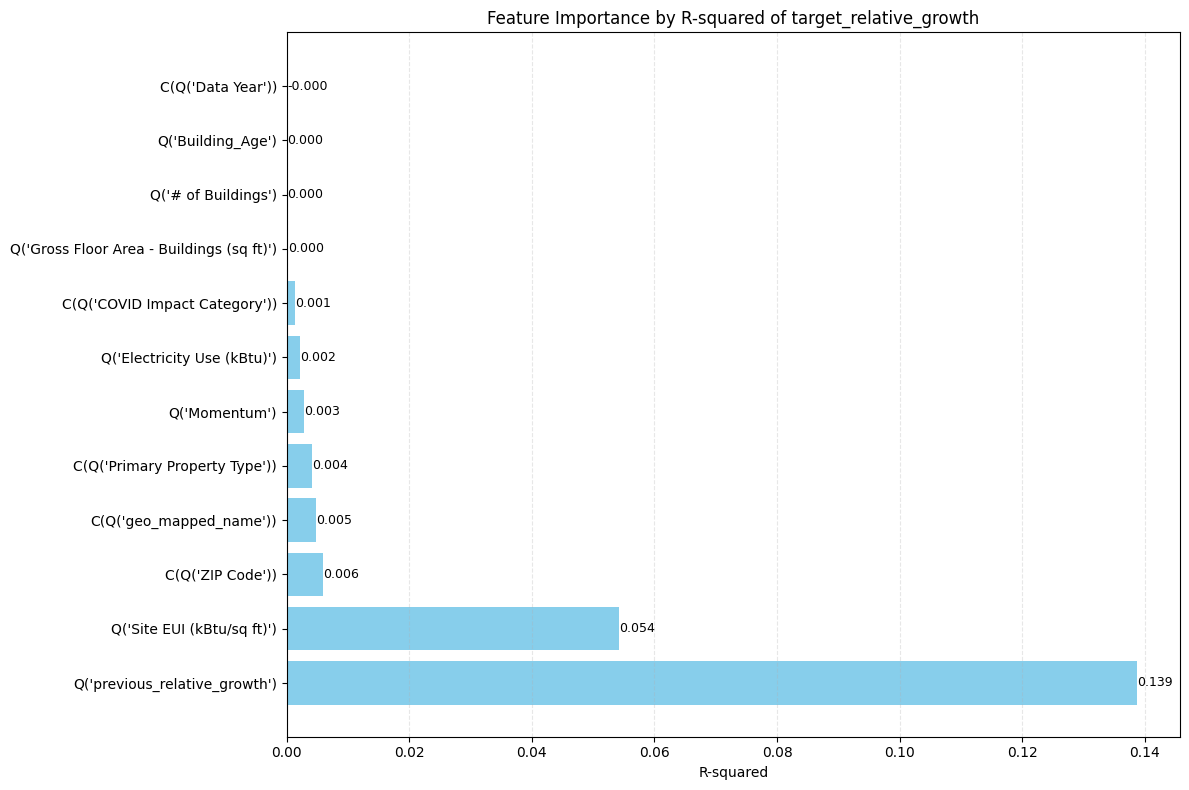

In [5]:
target_col = "target_relative_growth"
q_feature_cols = [
    "previous_relative_growth",
    "Momentum",
    "Gross Floor Area - Buildings (sq ft)",
    "# of Buildings",
    "Electricity Use (kBtu)",
    "Building_Age",
    "Site EUI (kBtu/sq ft)",
]
c_feature_cols = [
    "ZIP Code",
    "geo_mapped_name",
    "Primary Property Type",
    "COVID Impact Category",
    "Data Year",
]
plotting_r_sqared(target_col, q_feature_cols, c_feature_cols, train_df)

                                 OLS Regression Results                                
Dep. Variable:     Q('target_relative_growth')   R-squared:                       0.139
Model:                                     OLS   Adj. R-squared:                  0.139
Method:                          Least Squares   F-statistic:                     1010.
Date:                         Thu, 19 Feb 2026   Prob (F-statistic):          9.91e-206
Time:                                 21:02:07   Log-Likelihood:                -27063.
No. Observations:                         6270   AIC:                         5.413e+04
Df Residuals:                             6268   BIC:                         5.414e+04
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------

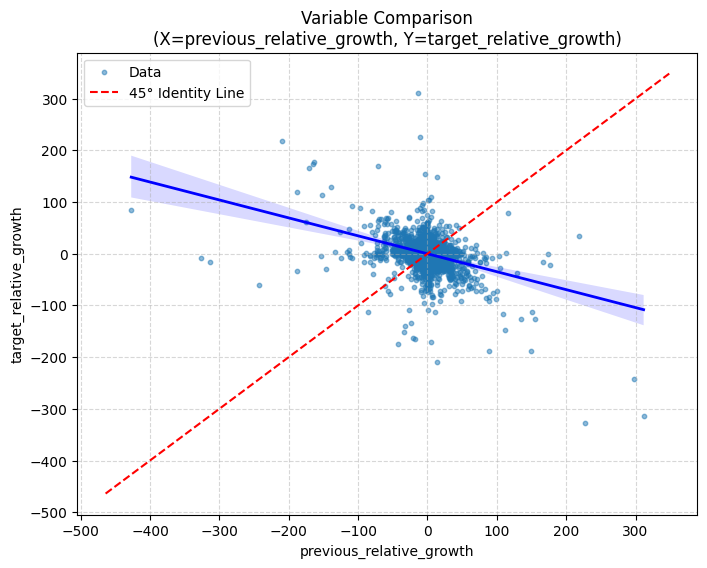

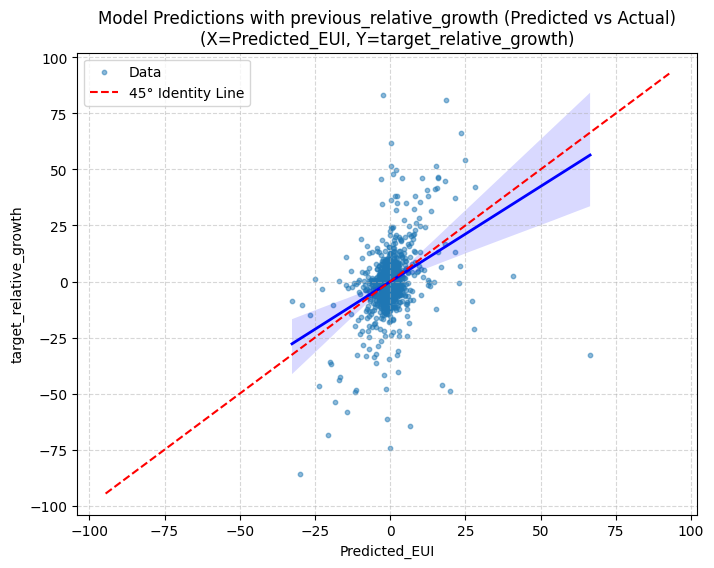

In [6]:
y_var = target_col
x_var = "previous_relative_growth"
formula = f"Q('{y_var}') ~ Q('{x_var}')"
ols_compare_and_pred_plot(formula, x_var, y_var, analysis_df, train_df, test_df)